# Option Pricing with Path Integrals

**AUTHOR**  
Rodrigo Kang

## Overview

This notebook accompanies the project **[Option Pricing with Path Integrals](https://rodrigokang.github.io/portfolio/1-quantitative-finance/3-option-pricing-with-path-integrals.html)** and contains the computational implementation supporting the methodology, experiments, and results discussed in the portfolio chapter.

The material presented here focuses on the numerical implementation of option pricing methods, including the Black–Scholes benchmark, standard Monte Carlo simulation, Metropolis–Hastings sampling, convergence analysis, and a simple market-data example.

## Imports and Configuration

This section initializes the main libraries used throughout the notebook.

The analysis combines analytical option pricing models, numerical integration techniques, and Monte Carlo simulation methods. Standard Python libraries are used for numerical computation, data manipulation, and visualization.

The objective is to implement and evaluate a path integral approach to option pricing under the assumptions of the Black–Scholes framework.

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Statistical functions
from scipy.stats import norm

# Reproducibility
np.random.seed(42)

# Display options
pd.options.display.float_format = "{:.6f}".format

# Plot configuration
plt.style.use("default")

## Black–Scholes Benchmark

The Black–Scholes model provides an analytical solution for pricing European call and put options under a set of simplifying assumptions. Throughout this notebook, the analytical Black–Scholes price is used as a benchmark to evaluate the numerical estimates obtained from the path integral formulation.

The implementation below defines a reusable function for computing European call option prices.

In [2]:
# Black-Scholes European Call Option

def black_scholes_call(S, K, T, r, sigma):
    """
    Compute the Black-Scholes price of a European call option.

    Inputs
    ------
    S : float
        Current asset price.

    K : float
        Strike price.

    T : float
        Time to maturity in years.

    r : float
        Risk-free interest rate.

    sigma : float
        Volatility.

    Outputs
    -------
    float
        European call option price.

    Author
    ------
    Rodrigo Kang
    """

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    call_price = (
        S * norm.cdf(d1)
        - K * np.exp(-r * T) * norm.cdf(d2)
    )

    return call_price

The following example uses a representative set of market parameters to compute the analytical option price.

In [3]:
# Example parameters

S = 100.0      # Current asset price
K = 100.0      # Strike price
T = 1.0        # One year to maturity
r = 0.05       # Risk-free rate
sigma = 0.20   # Volatility

bs_price = black_scholes_call(
    S=S,
    K=K,
    T=T,
    r=r,
    sigma=sigma
)

print(f"Black-Scholes Call Price: {bs_price:.4f}")

Black-Scholes Call Price: 10.4506


## Path Integral Pricing

The path integral formulation begins by representing the evolution of the underlying asset as a collection of possible price trajectories between the present time and the option's maturity.

Under the assumptions of the Black–Scholes framework, the asset follows a geometric Brownian motion. The continuous trajectory is approximated by discretizing the time horizon into a finite number of intervals. This transforms the original path integral into a multidimensional integration problem that can be evaluated numerically.

The first step is to define the model parameters and construct a discretized time grid.

In [4]:
# Model parameters

S0 = 100.0      # Initial asset price
K = 100.0       # Strike price
T = 1.0         # Maturity (years)
r = 0.05        # Risk-free rate
sigma = 0.20    # Volatility

# Time discretization

n_steps = 50
dt = T / n_steps

time_grid = np.linspace(0, T, n_steps + 1)

print(f"Number of time steps: {n_steps}")
print(f"Time increment (dt): {dt:.4f}")

Number of time steps: 50
Time increment (dt): 0.0200


The discretized trajectory is represented as a sequence of asset prices observed along the time grid. Under geometric Brownian motion, each increment depends on a deterministic drift component and a stochastic diffusion component.

The following function generates a single price trajectory.

In [5]:
def simulate_gbm_path(S0, r, sigma, T, n_steps):
    """
    Simulate a single Geometric Brownian Motion trajectory.

    Inputs
    ------
    S0 : float
        Initial asset price.

    r : float
        Risk-free interest rate.

    sigma : float
        Volatility.

    T : float
        Time to maturity in years.

    n_steps : int
        Number of discretization steps.

    Outputs
    -------
    numpy.ndarray
        Simulated asset price trajectory.

    Author
    ------
    Rodrigo Kang
    """

    dt = T / n_steps

    path = np.zeros(n_steps + 1)
    path[0] = S0

    for t in range(1, n_steps + 1):

        z = np.random.normal()

        path[t] = (
            path[t - 1]
            * np.exp(
                (r - 0.5 * sigma**2) * dt
                + sigma * np.sqrt(dt) * z
            )
        )

    return path

A simulated trajectory provides a visual representation of one possible evolution of the underlying asset under the model assumptions.

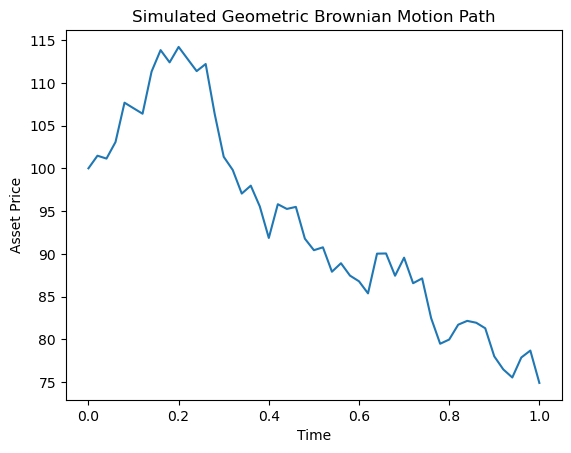

In [6]:
sample_path = simulate_gbm_path(
    S0=S0,
    r=r,
    sigma=sigma,
    T=T,
    n_steps=n_steps
)

plt.plot(time_grid, sample_path)

plt.xlabel("Time")
plt.ylabel("Asset Price")
plt.title("Simulated Geometric Brownian Motion Path")

plt.show()

## Monte Carlo Estimation

Monte Carlo simulation provides a natural baseline for option pricing when the underlying asset follows a stochastic process.

In this section, multiple price trajectories are simulated under geometric Brownian motion. The European call payoff is computed at maturity for each trajectory, and the option price is estimated as the discounted average payoff.

In [7]:
def monte_carlo_call_price(S0, K, T, r, sigma, n_steps, n_simulations):
    """
    Estimate the price of a European call option using Monte Carlo simulation.

    Inputs
    ------
    S0 : float
        Initial asset price.

    K : float
        Strike price.

    T : float
        Time to maturity in years.

    r : float
        Risk-free interest rate.

    sigma : float
        Volatility.

    n_steps : int
        Number of discretization steps.

    n_simulations : int
        Number of simulated price trajectories.

    Outputs
    -------
    float
        Monte Carlo estimate of the European call option price.

    Author
    ------
    Rodrigo Kang
    """

    payoffs = np.zeros(n_simulations)

    for i in range(n_simulations):

        path = simulate_gbm_path(
            S0=S0,
            r=r,
            sigma=sigma,
            T=T,
            n_steps=n_steps
        )

        ST = path[-1]
        payoffs[i] = max(ST - K, 0)

    price = np.exp(-r * T) * np.mean(payoffs)

    return price

In [8]:
# Monte Carlo estimation

n_simulations = 10000

mc_price = monte_carlo_call_price(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    n_steps=n_steps,
    n_simulations=n_simulations
)

bs_price = black_scholes_call(
    S=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma
)

print(f"Black-Scholes Call Price: {bs_price:.4f}")
print(f"Monte Carlo Call Price:   {mc_price:.4f}")
print(f"Absolute Difference:      {abs(mc_price - bs_price):.4f}")

Black-Scholes Call Price: 10.4506
Monte Carlo Call Price:   10.4039
Absolute Difference:      0.0467


The Monte Carlo estimate provides a simulation-based benchmark. Since the analytical Black–Scholes price is available for European calls, the difference between both values gives a first indication of the numerical accuracy of the simulation workflow.

## Metropolis–Hastings Estimation

As the number of discretization steps increases, the path integral formulation leads to high-dimensional integration problems that become increasingly difficult to evaluate through direct numerical methods.

Markov Chain Monte Carlo techniques provide an alternative strategy by generating representative samples from the target distribution. In this section, the Metropolis–Hastings algorithm is used to sample terminal log-prices implied by the risk-neutral geometric Brownian motion distribution. This simplified implementation is consistent with the European call setting, where the payoff depends only on the terminal asset price.

In [9]:
def european_call_payoff(ST, K):
    """
    Compute the payoff of a European call option.

    Inputs
    ------
    ST : float
        Asset price at maturity.

    K : float
        Strike price.

    Outputs
    -------
    float
        European call payoff.

    Author
    ------
    Rodrigo Kang
    """

    return max(ST - K, 0)

In [10]:
def metropolis_hastings_terminal_price(
    S0,
    K,
    T,
    r,
    sigma,
    n_samples,
    proposal_std
):
    """
    Estimate a European call price using
    Metropolis-Hastings sampling of terminal log-prices.
    
    This implementation samples from the terminal distribution
    of log(S_T) under risk-neutral geometric Brownian motion.
    It is appropriate for European options, whose payoff depends
    only on the terminal asset price.

    Inputs
    ------
    S0 : float
        Initial asset price.

    K : float
        Strike price.

    T : float
        Time to maturity in years.

    r : float
        Risk-free interest rate.

    sigma : float
        Volatility.

    n_samples : int
        Number of MCMC samples.

    proposal_std : float
        Standard deviation of proposal distribution.

    Outputs
    -------
    float
        Estimated European call option price.

    Author
    ------
    Rodrigo Kang
    """

    mu = np.log(S0) + (r - 0.5 * sigma**2) * T
    sigma_T = sigma * np.sqrt(T)

    current = np.random.normal(mu, sigma_T)

    payoffs = []

    for _ in range(n_samples):

        proposal = current + np.random.normal(
            0,
            proposal_std
        )

        current_density = norm.pdf(
            current,
            loc=mu,
            scale=sigma_T
        )

        proposal_density = norm.pdf(
            proposal,
            loc=mu,
            scale=sigma_T
        )

        acceptance_ratio = (
            proposal_density
            / current_density
        )

        if np.random.rand() < min(
            1,
            acceptance_ratio
        ):
            current = proposal

        ST = np.exp(current)

        payoffs.append(
            european_call_payoff(ST, K)
        )

    option_price = (
        np.exp(-r * T)
        * np.mean(payoffs)
    )

    return option_price

In [11]:
# Metropolis-Hastings estimation

mh_price = metropolis_hastings_terminal_price(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    n_samples=10000,
    proposal_std=0.15
)

print(f"Black-Scholes Price:     {bs_price:.4f}")
print(f"Monte Carlo Price:       {mc_price:.4f}")
print(f"Metropolis-Hastings:     {mh_price:.4f}")

Black-Scholes Price:     10.4506
Monte Carlo Price:       10.4039
Metropolis-Hastings:     9.6412


The Metropolis–Hastings estimate can now be compared against both the analytical Black–Scholes solution and the standard Monte Carlo estimate.

Agreement between the three methods provides evidence that the numerical implementation is correctly reproducing the pricing dynamics implied by the Black–Scholes framework.

## Comparison of Pricing Methods

The analytical Black–Scholes solution provides a reference value against which the numerical estimates can be evaluated.

This section compares the option prices obtained from the analytical formula, standard Monte Carlo simulation, and Metropolis–Hastings sampling. The objective is to assess the consistency of the numerical implementations and quantify any differences relative to the benchmark.

In [12]:
comparison_df = pd.DataFrame(
    {
        "Method": [
            "Black-Scholes",
            "Monte Carlo",
            "Metropolis-Hastings"
        ],
        "Option Price": [
            bs_price,
            mc_price,
            mh_price
        ]
    }
)

comparison_df["Absolute Error"] = (
    comparison_df["Option Price"]
    - bs_price
).abs()

comparison_df

,Method,Option Price,Absolute Error
0,Black-Scholes,10.450584,0.000000
1,Monte Carlo,10.403853,0.046731
2,Metropolis-Hastings,9.641164,0.809419


The table above summarizes the estimated option prices and their absolute deviation from the analytical benchmark.

Since the Black–Scholes solution is available for European call options, the numerical methods are expected to converge toward the analytical value as the number of samples increases.

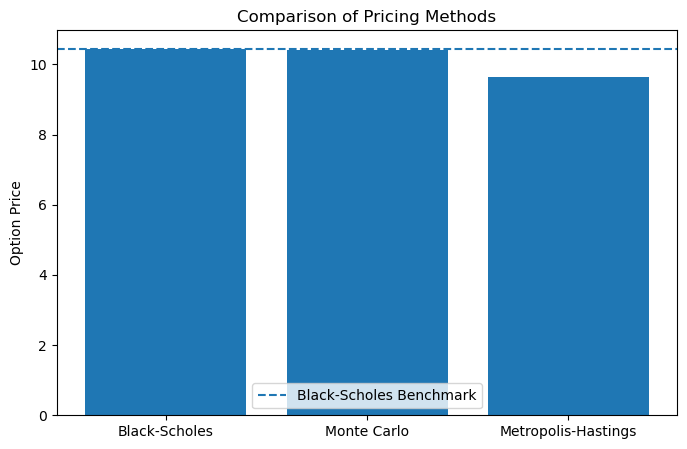

In [13]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Method"],
    comparison_df["Option Price"]
)

plt.axhline(
    bs_price,
    linestyle="--",
    label="Black-Scholes Benchmark"
)

plt.ylabel("Option Price")
plt.title("Comparison of Pricing Methods")
plt.legend()

plt.show()

Visual agreement between the three estimates provides a first indication that the simulation-based approaches are reproducing the dynamics implied by the Black–Scholes framework.

A more informative analysis can be obtained by studying the convergence of the Monte Carlo estimators as the number of samples increases.

## Convergence Analysis

Numerical estimates obtained through simulation are expected to converge toward the analytical Black–Scholes price as the number of samples increases.

This section evaluates the convergence behavior of both standard Monte Carlo simulation and Metropolis–Hastings sampling by comparing their estimates across different sample sizes.

In [14]:
sample_sizes = [
    100,
    500,
    1000,
    5000,
    10000
]

convergence_results = []

for n_samples in sample_sizes:

    mc_estimate = monte_carlo_call_price(
        S0=S0,
        K=K,
        T=T,
        r=r,
        sigma=sigma,
        n_steps=n_steps,
        n_simulations=n_samples
    )

    mh_estimate = metropolis_hastings_terminal_price(
        S0=S0,
        K=K,
        T=T,
        r=r,
        sigma=sigma,
        n_samples=n_samples,
        proposal_std=0.15
    )

    convergence_results.append(
        {
            "Samples": n_samples,
            "Monte Carlo": mc_estimate,
            "Metropolis-Hastings": mh_estimate,
            "Black-Scholes": bs_price
        }
    )

convergence_df = pd.DataFrame(
    convergence_results
)

convergence_df

,Samples,Monte Carlo,Metropolis-Hastings,Black-Scholes
0,100,9.079186,13.654078,10.450584
1,500,10.165790,18.856122,10.450584
2,1000,10.016866,12.279166,10.450584
3,5000,10.535070,10.684518,10.450584
4,10000,10.072597,10.094306,10.450584


The table summarizes the option prices obtained using different sample sizes. As the number of simulated trajectories increases, both numerical estimators should approach the analytical benchmark.

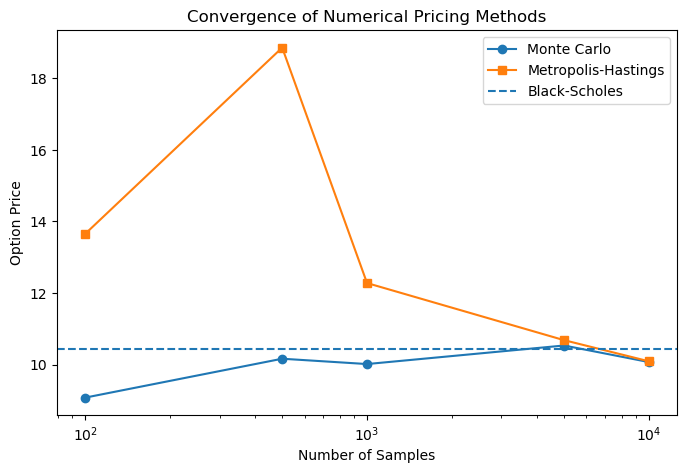

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    convergence_df["Samples"],
    convergence_df["Monte Carlo"],
    marker="o",
    label="Monte Carlo"
)

plt.plot(
    convergence_df["Samples"],
    convergence_df["Metropolis-Hastings"],
    marker="s",
    label="Metropolis-Hastings"
)

plt.axhline(
    bs_price,
    linestyle="--",
    label="Black-Scholes"
)

plt.xscale("log")

plt.xlabel("Number of Samples")
plt.ylabel("Option Price")
plt.title("Convergence of Numerical Pricing Methods")

plt.legend()

plt.show()

The convergence analysis provides additional validation of the numerical implementation. Agreement between the simulation-based estimates and the analytical benchmark indicates that the path integral framework is reproducing the pricing dynamics implied by the Black–Scholes model.

Having established consistency under controlled conditions, the next step is to evaluate the methodology using historical market data.

## Market Data Example

The previous sections focused on validating the numerical implementation under controlled conditions. While this provides confidence in the correctness of the algorithms, option pricing is ultimately applied to real financial assets.

This section illustrates a simple market application using historical price data obtained from Yahoo Finance. Historical returns are used to estimate the volatility parameter required by the Black–Scholes framework, and the resulting option prices are compared across the analytical and simulation-based methods.

The objective is not to calibrate a production-ready pricing model, but to demonstrate how the path integral workflow can be applied in a realistic setting.

In [16]:
# Financial data
import yfinance as yf

The example uses Apple Inc. as the underlying asset. Daily adjusted closing prices are downloaded and used to estimate annualized historical volatility.

In [17]:
ticker = "AAPL"

start_date = "2023-01-01"
end_date = "2024-01-01"

data = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    progress=False
)

prices = data["Close"][ticker]

prices.head()

Date
2023-01-03   122.982712
2023-01-04   124.251190
2023-01-05   122.933540
2023-01-06   127.456779
2023-01-09   127.977913
Name: AAPL, dtype: float64

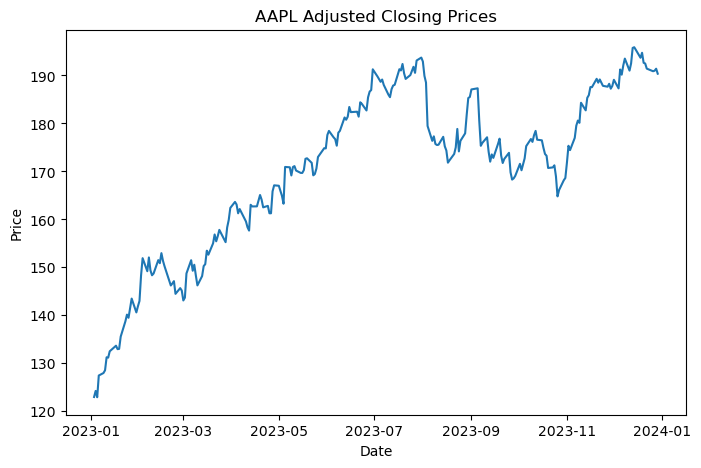

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(prices)

plt.title(f"{ticker} Adjusted Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

Historical volatility is estimated from daily log returns and annualized using the square-root-of-time rule.

In [19]:
log_returns = np.log(
    prices / prices.shift(1)
).dropna()

historical_volatility = (
    log_returns.std()
    * np.sqrt(252)
)

print(f"Annualized Historical Volatility: {historical_volatility:.4f}")

Annualized Historical Volatility: 0.1992


The most recent market price is used as the spot price of the underlying asset. For illustration purposes, the strike price is set equal to the current asset price, producing an at-the-money European call option.

In [20]:
S_market = float(prices.iloc[-1])
K_market = S_market

T_market = 1.0
r_market = 0.05
sigma_market = historical_volatility

print(f"Spot Price: {S_market:.2f}")
print(f"Strike Price: {K_market:.2f}")
print(f"Volatility: {sigma_market:.4f}")

Spot Price: 190.38
Strike Price: 190.38
Volatility: 0.1992


The option price is then estimated using the three methods developed throughout the notebook.

In [21]:
bs_market_price = black_scholes_call(
    S=S_market,
    K=K_market,
    T=T_market,
    r=r_market,
    sigma=sigma_market
)

mc_market_price = monte_carlo_call_price(
    S0=S_market,
    K=K_market,
    T=T_market,
    r=r_market,
    sigma=sigma_market,
    n_steps=n_steps,
    n_simulations=10000
)

mh_market_price = metropolis_hastings_terminal_price(
    S0=S_market,
    K=K_market,
    T=T_market,
    r=r_market,
    sigma=sigma_market,
    n_samples=10000,
    proposal_std=0.15
)

market_comparison = pd.DataFrame(
    {
        "Method": [
            "Black-Scholes",
            "Monte Carlo",
            "Metropolis-Hastings"
        ],
        "Option Price": [
            bs_market_price,
            mc_market_price,
            mh_market_price
        ]
    }
)

market_comparison["Absolute Error"] = (
    market_comparison["Option Price"]
    - bs_market_price
).abs()

market_comparison

,Method,Option Price,Absolute Error
0,Black-Scholes,19.839755,0.000000
1,Monte Carlo,19.993735,0.153980
2,Metropolis-Hastings,20.736170,0.896414


The results illustrate how the path integral framework can be integrated into a practical pricing workflow using market-derived inputs. Although the example remains intentionally simple, it demonstrates that the methodology extends naturally from controlled numerical experiments to realistic financial scenarios.

## Summary

This notebook implemented a computational workflow for pricing European call options using analytical and simulation-based methods.

The Black–Scholes formula was used as the analytical benchmark. Standard Monte Carlo simulation provided a conventional numerical reference, while the Metropolis–Hastings algorithm was used to estimate option prices from samples of the terminal risk-neutral distribution. In this simplified European option setting, this provides a sampling-based implementation aligned with the path integral perspective.

The results show that the numerical methods reproduce the Black–Scholes benchmark under controlled assumptions and can also be applied to a simple market-based example using historical volatility estimated from real price data. This provides a practical foundation for extending the framework to more complex derivatives where closed-form solutions are not available.